In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
##for dirname, _, filenames in os.walk('/kaggle/input'):
  ## for filename in filenames:
     ##   print(os.path.join(dirname, filename))
#
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
!pip install rapidfuzz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 34.0 MB/s eta 0:00:00


In [4]:
!kaggle datasets download -d urbikn/sroie-datasetv2

Dataset URL: https://www.kaggle.com/datasets/urbikn/sroie-datasetv2
License(s): other
100% 834M/834M [00:09<00:00, 95.7MB/s]



In [5]:
!unzip sroie-datasetv2.zip

Archive:  sroie-datasetv2.zip
  inflating: SROIE2019/layoutlm-base-uncased/config.json  
  inflating: SROIE2019/layoutlm-base-uncased/pytorch_model.bin  
  inflating: SROIE2019/layoutlm-base-uncased/special_tokens_map.json  
  inflating: SROIE2019/layoutlm-base-uncased/tokenizer_config.json  
  inflating: SROIE2019/layoutlm-base-uncased/training_args.bin  
  inflating: SROIE2019/layoutlm-base-uncased/vocab.txt  
  inflating: SROIE2019/test/box/X00016469670.txt  
  inflating: SROIE2019/test/box/X00016469671.txt  
  inflating: SROIE2019/test/box/X51005200931.txt  
  inflating: SROIE2019/test/box/X51005230605.txt  
  inflating: SROIE2019/test/box/X51005230616.txt  
  inflating: SROIE2019/test/box/X51005230621.txt  
  inflating: SROIE2019/test/box/X51005230648.txt  
  inflating: SROIE2019/test/box/X51005230657.txt  
  inflating: SROIE2019/test/box/X51005230659.txt  
  inflating: SROIE2019/test/box/X51005268275.txt  
  inflating: SROIE2019/test/box/X51005268408.txt  
  inflating: SROIE2019/

In [ ]:
import os

os.listdir("/content")

['.config', 'SROIE2019', 'sroie-datasetv2.zip', 'sample_data']

In [8]:
!which tesseract
!pip install pytesseract

/usr/bin/tesseract


In [9]:
import os
import json
import cv2
import numpy as np
import pytesseract
from PIL import Image

In [6]:
import os
import json

base_path = "/content/SROIE2019"

train_img_path = base_path + "/train/img"
train_box_path = base_path + "/train/box"
train_label_path = base_path + "/train/entities"

test_img_path = base_path + "/test/img"
test_box_path = base_path + "/test/box"
test_label_path = base_path + "/test/entities"

train_images = [os.path.join(train_img_path, f) for f in os.listdir(train_img_path)]
test_images = [os.path.join(test_img_path, f) for f in os.listdir(test_img_path)]


In [ ]:
def parse_line(line):
    parts = line.strip().split(",")

    if len(parts) < 9:
        return None, None

    try:
        coords = list(map(int, parts[:8]))
    except:
        return None, None

    text = ",".join(parts[8:]).strip()

    return coords, text

def polygon_to_box(coords):
    x = coords[0::2]
    y = coords[1::2]
    return [min(x), min(y), max(x), max(y)]

import cv2
import matplotlib.pyplot as plt

def visualize_from_raw(image_path, raw_lines):
    import cv2
    import matplotlib.pyplot as plt

    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    for line in raw_lines:
        coords, text = parse_line(line)

        if coords is None:
            continue

        x = coords[0::2]
        y = coords[1::2]

        x1, y1, x2, y2 = min(x), min(y), max(x), max(y)

        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img, text, (x1, y1 - 2),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4,
                    (255, 0, 0), 1)

    plt.figure(figsize=(15, 15))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

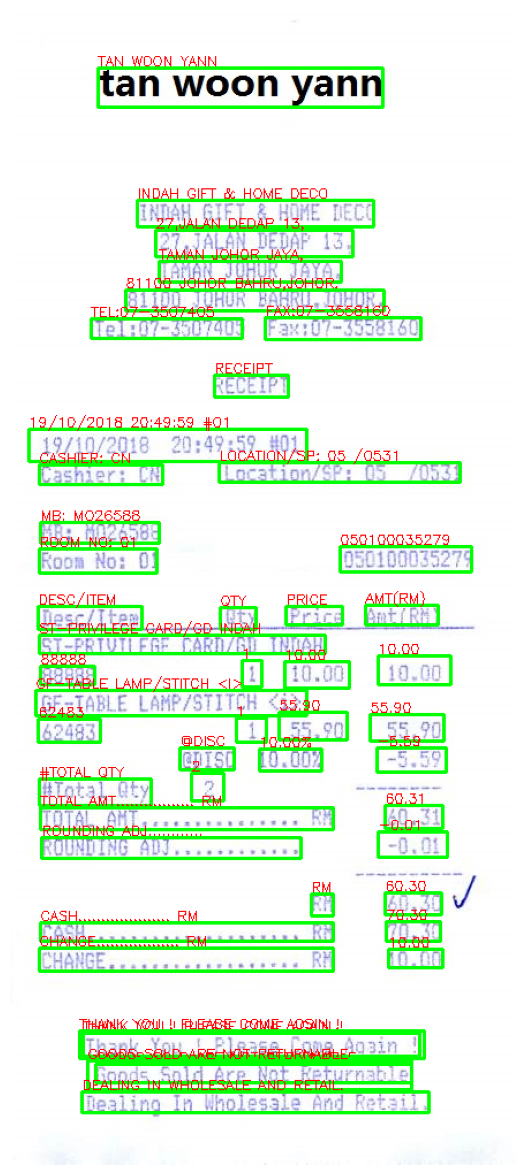

In [ ]:
box_path = "/kaggle/input/datasets/urbikn/sroie-datasetv2/SROIE2019/train/box/X00016469619.txt"

with open(box_path, "r", encoding="utf-8") as f:
    raw_lines = f.readlines()

raw_lines[:]

image_path = "/kaggle/input/datasets/urbikn/sroie-datasetv2/SROIE2019/train/img/X00016469619.jpg"

visualize_from_raw(image_path, raw_lines)

In [10]:
import cv2
import numpy as np
import pytesseract
from PIL import Image
import os
import json

# ❌ REMOVE Windows path (Kaggle/AWS already has tesseract installed)
# pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'


def load_image(image_path: str) -> np.ndarray:
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Image not found: {image_path}")

    image = cv2.imread(image_path)
    if image is None:
        raise ValueError(f"Could not read image: {image_path}")


    return image


def preprocess_image(image: np.ndarray) -> np.ndarray:
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # ---- 1. Resize consistently (important) ----
    h, w = gray.shape
    target_width = 1200

    if w != target_width:
        scale = target_width / w
        gray = cv2.resize(gray, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC)

    # ---- 2. Light denoising (not too aggressive) ----
    denoised = cv2.fastNlMeansDenoising(gray, None, h=10)

    # ---- 3. Improve contrast (VERY important for invoices) ----
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced = clahe.apply(denoised)

    # ---- 4. Adaptive threshold ----
    thresh = cv2.adaptiveThreshold(
        enhanced,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        15,
        4
    )

    return deskew(thresh)


def deskew(image: np.ndarray) -> np.ndarray:
    coords = np.column_stack(np.where(image > 0))
    if len(coords) == 0:
        return image

    angle = cv2.minAreaRect(coords)[-1]

    if angle < -45:
        angle = 90 + angle

    if abs(angle) < 0.5:
        return image

    (h, w) = image.shape[:2]
    center = (w // 2, h // 2)

    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    return cv2.warpAffine(image, M, (w, h),
                          flags=cv2.INTER_CUBIC,
                          borderMode=cv2.BORDER_REPLICATE)


import re

def is_valid_word(word):
    word = word.strip()

    if len(word) <= 2 and not word.isdigit():
        return False

    if not any(c.isalnum() for c in word):
        return False

    if word.lower() in ["oo", "ii", "ll"]:
        return False

    # keep numbers, dates, money, or real words
    if re.match(r"^[0-9]+(\.[0-9]+)?$", word):  # numbers like 9.00
        return True

    if re.match(r"\d{1,2}/\d{1,2}/\d{2,4}", word):  # dates
        return True

    # normal words
    return True


def run_ocr(processed_image: np.ndarray):
    pil_image = Image.fromarray(processed_image)

    config = r'--oem 3 --psm 6'

    words, boxes = [], []

    data = pytesseract.image_to_data(
        pil_image,
        config=config,
        output_type=pytesseract.Output.DICT
    )

    for i in range(len(data['text'])):

        word = data['text'][i].strip()
        conf = float(data['conf'][i])

        # ---- FILTER 1: confidence ----
        if conf < 55:
            continue

        # ---- FILTER 2: validity ----
        if not is_valid_word(word):
            continue

        # ---- FILTER 3: remove OCR garbage ----
        if any(c in word for c in ['@', '|', '•', '©', '$$']):
            continue

        words.append(word)

        boxes.append([
            data['left'][i],
            data['top'][i],
            data['left'][i] + data['width'][i],
            data['top'][i] + data['height'][i]
        ])

    return " ".join(words), words, boxes


import numpy as np


def process_invoice(image_path, output_dir="output"):
    os.makedirs(output_dir, exist_ok=True)

    base = os.path.splitext(os.path.basename(image_path))[0]

    img = load_image(image_path)
    processed = preprocess_image(img)

    text, words, boxes = run_ocr(processed)

    return text, words, boxes, processed

# TEST
image_path = "/content/SROIE2019/train/img/X51005301667.jpg"
process_invoice(image_path)

("GON) BED) ‘Nog 28) BANDAR RAIA, 40080) ROC Nos No, 00 395 8362 Stations Now Cashier: Date Stare: 20/11/2017 Code Nawwe IESWARAN' REFER TO59) SUR 1059 SQUARE BUACK 2 UND 1 sail Senvitce GSBATAX 6%. TOTAL, GASH CHANGE: 2 Qty You, cane Goods ane not BANK 28) AGE, HBB) 620 BANG ACC 888 123 3706). SRO Dus",
 ['GON)',
  'BED)',
  '‘Nog',
  '28)',
  'BANDAR',
  'RAIA,',
  '40080)',
  'ROC',
  'Nos',
  'No,',
  '00',
  '395',
  '8362',
  'Stations',
  'Now',
  'Cashier:',
  'Date',
  'Stare:',
  '20/11/2017',
  'Code',
  'Nawwe',
  "IESWARAN'",
  'REFER',
  'TO59)',
  'SUR',
  '1059',
  'SQUARE',
  'BUACK',
  '2',
  'UND',
  '1',
  'sail',
  'Senvitce',
  'GSBATAX',
  '6%.',
  'TOTAL,',
  'GASH',
  'CHANGE:',
  '2',
  'Qty',
  'You,',
  'cane',
  'Goods',
  'ane',
  'not',
  'BANK',
  '28)',
  'AGE,',
  'HBB)',
  '620',
  'BANG',
  'ACC',
  '888',
  '123',
  '3706).',
  'SRO',
  'Dus'],
 [[747, 439, 839, 487],
  [865, 429, 964, 486],
  [309, 526, 384, 567],
  [406, 536, 467, 570],
  [296, 54

In [ ]:
import os
import json

output_dir = "/kaggle/working/ocr_data"
os.makedirs(output_dir, exist_ok=True)

In [ ]:
train_outputs = []

for img_path in train_images:
    try:
        text, words, boxes, processed = process_invoice(img_path, output_dir="train_output")

        train_outputs.append({
            "image_path": img_path,
            "words": words,
            "boxes": boxes
        })

    except Exception as e:
        print("Error:", img_path, e)

Corrupt JPEG data: bad Huffman code


In [ ]:
with open(os.path.join(output_dir, "train.json"), "w") as f:
    json.dump(train_outputs, f)

In [ ]:
def visualizess_ocr(img, words, boxes):
    import cv2
    import matplotlib.pyplot as plt

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    for word, box in zip(words, boxes):
        x1, y1, x2, y2 = box

        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img, word, (x1, y1 - 2),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4,
                    (255, 0, 0), 1)

    plt.figure(figsize=(15, 15))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

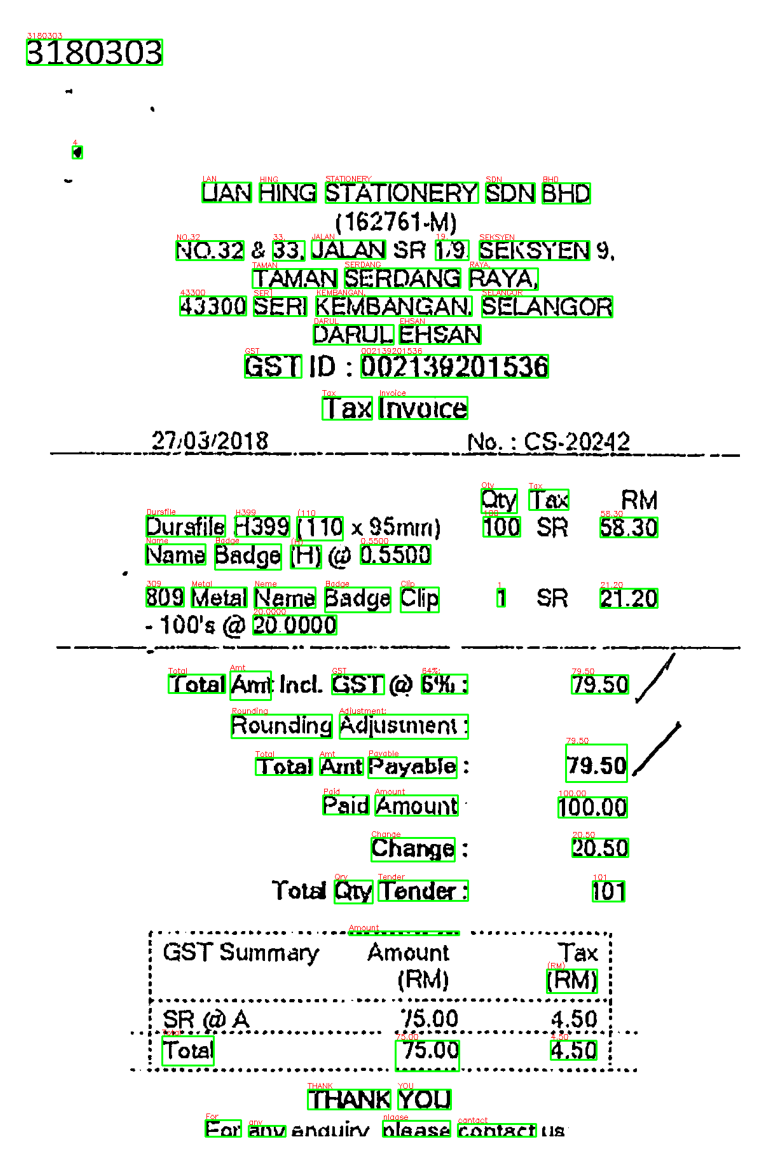

In [ ]:
import json

json_path = "/kaggle/input/datasets/habibaahmed200421/train-d/train(1).json"

with open(json_path, "r") as f:
    data = json.load(f)

sample = data[5]

image_path = sample["image_path"]

text, words, boxes, processed = process_invoice(image_path)

visualizess_ocr(processed, words, boxes)

In [ ]:
test_outputs = []

for img_path in test_images:
    try:
        text, words, boxes, processed = process_invoice(img_path, output_dir="test_output")

        test_outputs.append({
            "image_path": img_path,
            "words": words,
            "boxes": boxes
        })

    except Exception as e:
        print("Error:", img_path, e)

In [ ]:
with open(os.path.join(output_dir, "test.json"), "w") as f:
    json.dump(test_outputs, f)

In [51]:
import json

path = "/content/train(1).json"

with open(path, "r") as f:
    train_data = json.load(f)

In [52]:
import json

path = "/content/test(2).json"

with open(path, "r") as f:
    test_data = json.load(f)

In [53]:
import re
from rapidfuzz import fuzz

In [54]:
def normalize_text(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", " ", text)   # keep letters + numbers
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [55]:
def normalize_number(text):
    text = text.lower().strip()

    # unify separators
    text = text.replace(",", ".")
    text = re.sub(r"[^0-9./:-]", " ", text)

    # collapse spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [56]:
def is_number(x):
    return bool(re.fullmatch(r"\d+(\.\d+)?", x))

In [57]:
def is_date(x):
    return bool(re.fullmatch(r"\d{1,2}[-/]\d{1,2}[-/]\d{2,4}", x))

In [58]:
def split_entity(value, key):
    value = normalize(value)

    # DATE handling
    if "date" in key:
        return re.split(r"[^\d]+", value)  # keep numbers only

    # TOTAL handling
    if "total" in key:
        return re.findall(r"\d+\.\d+|\d+", value)

    # ADDRESS / COMPANY
    return value.split()

In [59]:
def load_gt_word_level(image_id):

    path = f"{base_path}/train/entities/{image_id}.txt"

    with open(path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    entities = {
        "company": [],
        "date": [],
        "address": [],
        "total": []
    }

    for line in lines:
        if ":" not in line:
            continue

        key, value = line.split(":", 1)
        key = key.lower().strip()

        # 🔥 TEXT FIELDS
        if "company" in key or "address" in key:
            value_words = normalize_text(value).split()

        # 🔥 NUMBER FIELDS
        elif "date" in key or "total" in key:
            value_words = normalize_number(value).split()

        else:
            continue

        if "company" in key:
            entities["company"] += value_words
        elif "address" in key:
            entities["address"] += value_words
        elif "date" in key:
            entities["date"] += value_words
        elif "total" in key:
            entities["total"] += value_words

    return entities

In [60]:
def load_gt_test(image_id):

    path = f"{base_path}/test/entities/{image_id}.txt"

    with open(path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    entities = {
        "company": [],
        "date": [],
        "address": [],
        "total": []
    }

    for line in lines:
        if ":" not in line:
            continue

        key, value = line.split(":", 1)
        key = key.lower().strip()

        # 🔥 TEXT FIELDS
        if "company" in key or "address" in key:
            value_words = normalize_text(value).split()

        # 🔥 NUMBER FIELDS
        elif "date" in key or "total" in key:
            value_words = normalize_number(value).split()

        else:
            continue

        if "company" in key:
            entities["company"] += value_words
        elif "address" in key:
            entities["address"] += value_words
        elif "date" in key:
            entities["date"] += value_words
        elif "total" in key:
            entities["total"] += value_words

    return entities

In [61]:
def label_word(word, entities, threshold=80):

    # dates → use normalize_number
    word_n = normalize_number(word)
    if is_date(word_n):
        for gt_w in entities["date"]:
            gt_n = normalize_number(gt_w)
            if gt_n in word_n or word_n in gt_n:
                return "DATE"

    # numbers → use normalize_number + exact match
    if is_number(word_n):
        for label, words_list in entities.items():
            for gt_w in words_list:
                gt_n = normalize_number(gt_w)
                if is_number(gt_n) and word_n == gt_n:
                    return label.upper()
        return "O"

    # text (company, address) → use normalize_text + fuzzy
    word_n = normalize_text(word)
    best_label = "O"
    best_score = 0
    for label, words_list in entities.items():
        for gt_w in words_list:
            score = fuzz.ratio(word_n, normalize_text(gt_w))
            if score > best_score:
                best_score = score
                best_label = label.upper()

    return best_label if best_score >= threshold else "O"

In [62]:
def assign_labels(words, entities):

    return [label_word(w, entities) for w in words]

In [63]:
def to_bio_labels(labels):
    """
    Convert:
    COMPANY COMPANY O ADDRESS ADDRESS
    →
    B-COMPANY I-COMPANY O B-ADDRESS I-ADDRESS
    """

    bio_labels = []

    prev_label = "O"

    for label in labels:

        # outside
        if label == "O":
            bio_labels.append("O")

        else:

            # start of new entity
            if label != prev_label:
                bio_labels.append(f"B-{label}")

            # continuation
            else:
                bio_labels.append(f"I-{label}")

        prev_label = label

    return bio_labels

In [64]:
sample = train_data[50]
image_path = sample["image_path"]
words = sample["words"]
boxes = sample["boxes"]
image_id = os.path.basename(image_path).replace(".jpg", "")

entities = load_gt_word_level(image_id)
labels = assign_labels(words, entities)
bio_labels = to_bio_labels(labels)
for w, l in list(zip(words, bio_labels))[:20]:
    print(w, "→", l)

print(words)
print(entities)
print("boxes:", len(boxes))
print("labels:", len(labels))

IDEAL → B-COMPANY
MENU → I-COMPANY
GROUP → I-COMPANY
SDN → I-COMPANY
BHD → I-COMPANY
(1143656-H) → O
31,31A, → O
JALAN → B-ADDRESS
HANG → I-ADDRESS
TUAH → I-ADDRESS
TAMAN → I-ADDRESS
BARU, → I-ADDRESS
81306 → O
SKUDAI, → B-ADDRESS
GST → O
001707421696 → O
TAX → O
INVOICE → O
10 → O
Date! → O
['IDEAL', 'MENU', 'GROUP', 'SDN', 'BHD', '(1143656-H)', '31,31A,', 'JALAN', 'HANG', 'TUAH', 'TAMAN', 'BARU,', '81306', 'SKUDAI,', 'GST', '001707421696', 'TAX', 'INVOICE', '10', 'Date!', '10/06/2018', 'SMCASHIER', 'Description', 'Qty', 'Price', 'Tax_', 'BAK', 'RICE', 'SET', '4', '12.00', 'BUBBLE', 'GREEN', 'TEA', '1', '0.00', 'Total:', 'Total', 'Sales', '(Excluding', 'GST', '12,00', 'Discount', '0.00', 'Charge', '0.00', 'TotalGST', '0.00', 'Rounding', 'Total', 'Sales', '(Inclusive', 'GST)', 'CASH', 'CHANGE', '8.00', 'Amt(RM)', 'Tax(RM)', '12.00', '0.00', 'Total:', '12.00', '0.00', 'this', 'Tax', 'coda', 'belong', 'charges.', 'THANK', 'YOU,', 'PLEASE', 'COME', 'AGAIN']
{'company': ['ideal', 'menu', '

In [65]:
bio_train_data = []

for sample in train_data:

    image_path = sample["image_path"]
    words = sample["words"]
    boxes = sample["boxes"]

    image_id = os.path.basename(image_path).replace(".jpg", "")

    # load GT entities
    entities = load_gt_word_level(image_id)

    # generate normal labels
    labels = assign_labels(words, entities)

    # convert to BIO
    bio_labels = to_bio_labels(labels)

    bio_train_data.append({
        "image_path": image_path,
        "words": words,
        "boxes": boxes,
        "labels": bio_labels
    })

print("✅ BIO dataset created:", len(bio_train_data))

✅ BIO dataset created: 626


In [66]:
bio_test_data = []

for sample in test_data:

    image_path = sample["image_path"]
    words = sample["words"]
    boxes = sample["boxes"]

    image_id = os.path.basename(image_path).replace(".jpg", "")

    # load GT entities
    entities = load_gt_test(image_id)

    # generate normal labels
    labels = assign_labels(words, entities)

    # convert to BIO
    bio_labels = to_bio_labels(labels)

    bio_test_data.append({
        "image_path": image_path,
        "words": words,
        "boxes": boxes,
        "labels": bio_labels
    })

print("✅ BIO dataset created:", len(bio_test_data))

✅ BIO dataset created: 347


In [ ]:
import json

train_path = "/kaggle/input/datasets/habibaahmed200421/dataset/train(1).json"

with open(train_path, "r") as f:
    train_data = json.load(f)

print("✅ Loaded samples:", len(train_data))

✅ Loaded samples: 626


In [ ]:
import json

test_path = "/kaggle/input/datasets/habibaahmed200421/dataset/test(2).json"

with open(test_path, "r") as f:
    test_data = json.load(f)

print("✅ Loaded samples:", len(test_data))

✅ Loaded samples: 347


In [67]:
label_list = [
    "O",
    "B-COMPANY",  "I-COMPANY",
    "B-DATE",     "I-DATE",
    "B-ADDRESS",  "I-ADDRESS",
    "B-TOTAL",    "I-TOTAL",
]

label2id = {l: i for i, l in enumerate(label_list)}
id2label = {i: l for l, i in label2id.items()}

print("✅ label2id:", label2id)
print("✅ id2label:", id2label)

✅ label2id: {'O': 0, 'B-COMPANY': 1, 'I-COMPANY': 2, 'B-DATE': 3, 'I-DATE': 4, 'B-ADDRESS': 5, 'I-ADDRESS': 6, 'B-TOTAL': 7, 'I-TOTAL': 8}
✅ id2label: {0: 'O', 1: 'B-COMPANY', 2: 'I-COMPANY', 3: 'B-DATE', 4: 'I-DATE', 5: 'B-ADDRESS', 6: 'I-ADDRESS', 7: 'B-TOTAL', 8: 'I-TOTAL'}


In [69]:
for sample in bio_train_data:

    filename = os.path.basename(sample["image_path"])

    sample["image_path"] = os.path.join(
        train_img_path,
        filename
    )

In [70]:
for sample in bio_test_data:

    filename = os.path.basename(sample["image_path"])

    sample["image_path"] = os.path.join(
        test_img_path,
        filename
    )

In [68]:
import cv2
import torch
from transformers import LayoutLMTokenizerFast

# =========================================================
# TOKENIZER
# =========================================================

tokenizer = LayoutLMTokenizerFast.from_pretrained(
    "microsoft/layoutlm-base-uncased"
)

def normalize_box(box, width, height):

    x0, y0, x1, y1 = box

    return [
        int(1000 * x0 / width),
        int(1000 * y0 / height),
        int(1000 * x1 / width),
        int(1000 * y1 / height),
    ]

# =========================================================
# DEBUG FUNCTION
# =========================================================

def debug_alignment(words, labels, boxes):

    print("\n========== DEBUG ==========")

    print(f"Words  : {len(words)}")
    print(f"Labels : {len(labels)}")
    print(f"Boxes  : {len(boxes)}")

    # ---- length checks ----
    assert len(words) == len(labels), \
        "❌ words and labels length mismatch"

    assert len(words) == len(boxes), \
        "❌ words and boxes length mismatch"

    # ---- box checks ----
    for i, b in enumerate(boxes):

        assert len(b) == 4, \
            f"❌ Invalid box at index {i}"

        x0, y0, x1, y1 = b

        assert x0 <= x1, \
            f"❌ Invalid X box at index {i}"

        assert y0 <= y1, \
            f"❌ Invalid Y box at index {i}"

    print("✅ Basic checks passed")

# =========================================================
# PREPROCESS FUNCTION
# =========================================================

def preprocess_sample(sample, tokenizer, label2id, debug=False):

    words = sample["words"]
    boxes = sample["boxes"]
    labels = sample["labels"]

    # -----------------------------------------------------
    # DEBUGGING
    # -----------------------------------------------------

    if debug:
        debug_alignment(words, labels, boxes)

    # -----------------------------------------------------
    # IMAGE CHECK
    # -----------------------------------------------------

    img = cv2.imread(sample["image_path"])

    if img is None:
        print(f"⚠️ Missing image: {sample['image_path']}")
        return None

    orig_h, orig_w = img.shape[:2]

    # your OCR resize width
    proc_w = 1200
    proc_h = int(orig_h * (proc_w / orig_w))

    # -----------------------------------------------------
    # NORMALIZE BOXES (IMPORTANT FIX)
    # -----------------------------------------------------

    boxes = [
        normalize_box(b, proc_w, proc_h)
        for b in boxes
    ]
    # -----------------------------------------------------
    # TOKENIZATION
    # -----------------------------------------------------

    encoding = tokenizer(
        words,
        boxes=boxes,
        is_split_into_words=True,
        truncation=True,
        padding="max_length",
        max_length=512,
        return_offsets_mapping=True
    )

    word_ids = encoding.word_ids()

    aligned_labels = []
    aligned_boxes = []

    previous_word_idx = None

    # =====================================================
    # LABEL ALIGNMENT
    # =====================================================

    for token_idx, word_idx in enumerate(word_ids):

        # special tokens like [CLS], [SEP], [PAD]
        if word_idx is None:

            aligned_labels.append(-100)
            aligned_boxes.append([0, 0, 0, 0])

            previous_word_idx = None
            continue

        # use same box for all subtokens
        aligned_boxes.append(boxes[word_idx])

        # first token of word
        if word_idx != previous_word_idx:

            label = labels[word_idx]

            if label not in label2id:
                raise ValueError(f"❌ Unknown label: {label}")

            aligned_labels.append(label2id[label])

        # subword token
        else:

            aligned_labels.append(-100)

        previous_word_idx = word_idx

    # =====================================================
    # FINAL DEBUG
    # =====================================================

    if debug:

        print("\n====== TOKEN DEBUG ======")

        tokens = tokenizer.convert_ids_to_tokens(
            encoding["input_ids"]
        )

        for i in range(min(50, len(tokens))):

            token = tokens[i]
            wid = word_ids[i]
            lab = aligned_labels[i]

            print(
                f"{i:03d} | "
                f"Token: {token:15} | "
                f"WordID: {str(wid):5} | "
                f"Label: {lab}"
            )

    # =====================================================
    # RETURN
    # =====================================================

    return {

        # model inputs
        "input_ids": torch.tensor(
            encoding["input_ids"],
            dtype=torch.long
        ),

        "attention_mask": torch.tensor(
            encoding["attention_mask"],
            dtype=torch.long
        ),

        "bbox": torch.tensor(
            aligned_boxes,
            dtype=torch.long
        ),

        "labels": torch.tensor(
            aligned_labels,
            dtype=torch.long
        ),

        # IMPORTANT FOR INFERENCE / DEBUGGING
        "tokens": tokenizer.convert_ids_to_tokens(
            encoding["input_ids"]
        ),

        "word_ids": word_ids,

        "words": words,

        "raw_labels": labels,

        "boxes_raw": boxes,

        # useful later for decoding predictions
        "id2label": {
            v: k for k, v in label2id.items()
        }
    }


In [71]:
train_processed = []

removed_samples = 0

for i, sample in enumerate(bio_train_data):

    result = preprocess_sample(
        sample,
        tokenizer,
        label2id,
        debug=(i == 0)   # debug first sample only
    )

    # skip failed preprocessing
    if result is None:
        removed_samples += 1
        continue

    # ============================================
    # CHECK INVALID BBOX
    # ============================================

    boxes = result["bbox"]

    if boxes.max() > 1000 or boxes.min() < 0:

        print(f"❌ Removed invalid bbox sample: {i}")
        print("Min:", boxes.min().item())
        print("Max:", boxes.max().item())

        removed_samples += 1
        continue

    # ============================================
    # KEEP VALID SAMPLE
    # ============================================

    train_processed.append(result)

    if i % 100 == 0:
        print(f"Processed {i} samples")

print("\n✅ Total valid processed:", len(train_processed))
print("❌ Removed samples:", removed_samples)
# ✅ 2. ADD THE DIAGNOSTIC RIGHT HERE ← ← ←
from collections import Counter

all_labels_flat = []
for sample in train_processed:
    for l in sample["labels"].tolist():
        if l != -100:
            all_labels_flat.append(id2label[l])

counts = Counter(all_labels_flat)
for label, count in counts.most_common():
    print(f"{label:20s}: {count:6d}  ({100*count/len(all_labels_flat):.1f}%)")


========== DEBUG ==========
Words  : 59
Labels : 59
Boxes  : 59
✅ Basic checks passed

====== TOKEN DEBUG ======
000 | Token: [CLS]           | WordID: None  | Label: -100
001 | Token: un              | WordID: 0     | Label: 1
002 | Token: ##ih            | WordID: 0     | Label: -100
003 | Token: ##ak            | WordID: 0     | Label: -100
004 | Token: ##ka            | WordID: 0     | Label: -100
005 | Token: international   | WordID: 1     | Label: 2
006 | Token: sd              | WordID: 2     | Label: 2
007 | Token: ##n             | WordID: 2     | Label: -100
008 | Token: b               | WordID: 3     | Label: 2
009 | Token: ##hd            | WordID: 3     | Label: -100
010 | Token: 05              | WordID: 4     | Label: 3
011 | Token: may             | WordID: 5     | Label: 0
012 | Token: 2018            | WordID: 6     | Label: 3
013 | Token: 18              | WordID: 7     | Label: 0
014 | Token: :               | WordID: 7     | Label: -100
015 | Token: 21          

In [ ]:
import torch

save_path = "/content/train_processed.json"

torch.save(
    {
        "data": train_processed
    },
    save_path
)

print("✅ Saved to:", save_path)

✅ Saved to: /content/train_processed.json


In [1]:
import torch

data = torch.load("/content/train_processed(6).json")

train_processed = data["data"]

print(len(train_processed))


626


In [72]:
test_processed = []

removed_samples = 0

for i, sample in enumerate(bio_test_data):

    result = preprocess_sample(
        sample,
        tokenizer,
        label2id,
        debug=(i == 0)   # debug first sample only
    )

    # skip failed preprocessing
    if result is None:
        removed_samples += 1
        continue

    # ============================================
    # CHECK INVALID BBOX
    # ============================================

    boxes = result["bbox"]

    if boxes.max() > 1000 or boxes.min() < 0:

        print(f"❌ Removed invalid bbox sample: {i}")
        print("Min:", boxes.min().item())
        print("Max:", boxes.max().item())

        removed_samples += 1
        continue

    # ============================================
    # KEEP VALID SAMPLE
    # ============================================

    test_processed.append(result)

    if i % 100 == 0:
        print(f"Processed {i} samples")

print("\n✅ Total valid processed:", len(test_processed))
print("❌ Removed samples:", removed_samples)


========== DEBUG ==========
Words  : 86
Labels : 86
Boxes  : 86
✅ Basic checks passed

====== TOKEN DEBUG ======
000 | Token: [CLS]           | WordID: None  | Label: -100
001 | Token: 4               | WordID: 0     | Label: 0
002 | Token: hen             | WordID: 1     | Label: 1
003 | Token: ##g             | WordID: 1     | Label: -100
004 | Token: ke              | WordID: 2     | Label: 2
005 | Token: ##e             | WordID: 2     | Label: -100
006 | Token: delight         | WordID: 3     | Label: 2
007 | Token: ##s             | WordID: 3     | Label: -100
008 | Token: ba              | WordID: 4     | Label: 2
009 | Token: ##k             | WordID: 4     | Label: -100
010 | Token: ku              | WordID: 5     | Label: 2
011 | Token: ##t             | WordID: 5     | Label: -100
012 | Token: te              | WordID: 6     | Label: 2
013 | Token: ##h             | WordID: 6     | Label: -100
014 | Token: .               | WordID: 6     | Label: -100
015 | Token: jalan    

In [ ]:
import torch

save_path = "/content/test_processed.json"

torch.save(
    {
        "data": test_processed
    },
    save_path
)

print("✅ Saved to:", save_path)

✅ Saved to: /content/test_processed.json


In [2]:
import torch

data = torch.load("/content/test_processed(5).json")

test_processed = data["data"]

print(len(test_processed))

347


In [73]:
print(train_processed[0].keys())
print(len(train_processed[0]["input_ids"]))
print(len(train_processed[0]["labels"]))
print(len(train_processed[0]["bbox"]))

dict_keys(['input_ids', 'attention_mask', 'bbox', 'labels', 'tokens', 'word_ids', 'words', 'raw_labels', 'boxes_raw', 'id2label'])
512
512
512


In [86]:
import torch

class InvoiceDataset(torch.utils.data.Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]

        # Works whether item values are tensors OR plain lists (from JSON)
        return {
            "input_ids": item["input_ids"].clone().detach().long(),
            "attention_mask": item["attention_mask"].clone().detach().long(),
            "bbox": item["bbox"].clone().detach().long(),
            "labels": item["labels"].clone().detach().long(),
        }

In [87]:
from sklearn.model_selection import train_test_split

train_data, val_data = train_test_split(train_processed, test_size=0.1, random_state=42)

In [88]:
from torch.utils.data import DataLoader

train_loader = DataLoader(InvoiceDataset(train_data), batch_size=2, shuffle=True)
val_loader = DataLoader(InvoiceDataset(val_data), batch_size=2)


In [89]:
test_loader = DataLoader(InvoiceDataset(test_processed), batch_size=2)


In [174]:
from transformers import LayoutLMForTokenClassification

model = LayoutLMForTokenClassification.from_pretrained(
    "microsoft/layoutlm-base-uncased",
    num_labels=len(label2id),
    label2id=label2id,
    id2label=id2label
)

model.to(device)

# No freezing — train the full model
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-5,
    weight_decay=0.01
)

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

LayoutLMForTokenClassification LOAD REPORT from: microsoft/layoutlm-base-uncased
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [175]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

LayoutLMForTokenClassification(
  (layoutlm): LayoutLMModel(
    (embeddings): LayoutLMEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (x_position_embeddings): Embedding(1024, 768)
      (y_position_embeddings): Embedding(1024, 768)
      (h_position_embeddings): Embedding(1024, 768)
      (w_position_embeddings): Embedding(1024, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): LayoutLMEncoder(
      (layer): ModuleList(
        (0-11): 12 x LayoutLMLayer(
          (attention): LayoutLMAttention(
            (self): LayoutLMSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
 

In [180]:
def run_eval(model, loader):

    model.eval()

    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():

        for batch in loader:

            batch = {k: v.to(device) for k, v in batch.items()}

            outputs = model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
                labels=batch["labels"]
            )

            # ✅ FIX HERE
            loss = outputs.loss
            logits = outputs.logits

            total_loss += loss.item()

            preds = torch.argmax(logits, dim=-1)

            preds = preds.detach().cpu().numpy()
            labels = batch["labels"].detach().cpu().numpy()

            mask = labels != -100

            all_preds.extend(preds[mask])
            all_labels.extend(labels[mask])

    f1 = f1_score(all_labels, all_preds, average="macro")

    return total_loss / len(loader), f1

In [181]:
all_labels = set()

for sample in train_processed:

    labels = sample["labels"]

    for l in labels.tolist():

        if l != -100:
            all_labels.add(l)

print("Labels found:", sorted(all_labels))
print("Num labels:", len(label2id))

Labels found: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Num labels: 9


In [167]:
!pip install pytorch-crf

In [182]:
from torchcrf import CRF
import torch.nn as nn

class NERModel(nn.Module):
    def __init__(self, base_model, num_labels):
        super().__init__()
        self.base = base_model
        self.classifier = nn.Linear(base_model.config.hidden_size, num_labels)
        self.crf = CRF(num_labels, batch_first=True)

    def forward(self, input_ids, attention_mask, labels=None):

        outputs = self.base(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        emissions = self.classifier(outputs.last_hidden_state)

        if labels is not None:
            loss = -self.crf(emissions, labels, mask=attention_mask.bool())
            return loss

        return self.crf.decode(emissions, mask=attention_mask.bool())

In [183]:

import torch
import torch.nn as nn
import numpy as np
from sklearn.metrics import f1_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print("✅ Weights:", weights)

loss_fct = torch.nn.CrossEntropyLoss(
    weight=weights,   # optional but OK
    ignore_index=-100
)


def check_collapse(preds, id2label):

    counts = np.bincount(preds, minlength=len(id2label))

    print("\n===== LABEL DISTRIBUTION =====")
    for i, c in enumerate(counts):
        print(f"{id2label[i]}: {c}")

    ratio = np.max(counts) / (np.sum(counts) + 1e-9)

    if ratio > 0.85:
        print("\n⚠️ WARNING: MODEL STILL COLLAPSING")
    else:
        print("\n✅ MODEL LEARNING MULTIPLE ENTITIES")


# =========================================================
# TRAIN LOOP (FIXED + DEBUG)
# =========================================================

best_val_f1 = 0

for epoch in range(5):

    model.train()

    train_loss = 0
    all_preds = []
    all_labels = []

    for i, batch in enumerate(train_loader):

        batch = {k: v.to(device) for k, v in batch.items()}

        labels = batch["labels"]

        # =========================
        # 🔥 O DROPOUT (OK)
        # =========================
        o_mask = (labels == label2id["O"])
        drop = (torch.rand_like(labels.float()) < 0.3) & o_mask

        labels = labels.clone()
        labels[drop] = -100
        batch["labels"] = labels

        # =========================
        # 🔥 FORWARD PASS
        # =========================
        outputs = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels=batch["labels"]
        )

        loss = outputs.loss
        logits = outputs.logits

        # =========================
        # BACKWARD
        # =========================
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        optimizer.zero_grad()

        train_loss += loss.item()

        # =========================
        # 🔥 PREDICTIONS (FIXED)
        # =========================
        preds = torch.argmax(logits, dim=-1)

        preds = preds.detach().cpu().numpy()
        labels_np = batch["labels"].detach().cpu().numpy()

        mask = labels_np != -100

        all_preds.extend(preds[mask])
        all_labels.extend(labels_np[mask])

        # =========================
        # DEBUG DISTRIBUTION
        # =========================
        if i % 50 == 0:
            print(np.bincount(preds[mask], minlength=len(id2label)))

    # =========================
    # METRICS
    # =========================
    train_loss /= len(train_loader)
    train_f1 = f1_score(all_labels, all_preds, average="macro")

    val_loss, val_f1 = run_eval(model, val_loader)

    print(f"\nEpoch {epoch+1}")
    print(f"Loss: {train_loss:.4f}")
    print(f"Train F1: {train_f1:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), "/content/best_model.pt")
        print("🔥 Saved Best Model")

✅ Weights: tensor([2.8233e-05, 1.0738e-03, 7.9074e-04, 1.8078e-03, 9.5996e-01, 5.2087e-04,
        3.1067e-04, 1.2229e-03, 3.4284e-02], device='cuda:0')
[94  1  4  2  0  0 19  0  0]
[30  3  3  0  0  0 11  0  0]
[36  2  3  3  0  3  4  2  0]
[76  2  9  3  0  5 18  1  0]
[47  2  4  2  0  4 12  0  0]
[86  2  5  1  0  7 13  2  0]

Epoch 1
Loss: 0.3160
Train F1: 0.6623
Val Loss: 0.2420 | Val F1: 0.6264
🔥 Saved Best Model
[69  2  3  2  0  6  1  6  0]
[80  2  4  3  0  4 14  4  0]
[137   2   6   2   0   4  19   2   0]
[50  2  3  1  0  2  5  3  0]
[75  1  4  2  0  4 11  2  0]
[61  2  3  1  0  4 13  1  0]

Epoch 2
Loss: 0.2315
Train F1: 0.7308
Val Loss: 0.2181 | Val F1: 0.6433
🔥 Saved Best Model
[70  3  3  2  0  5 11  6  0]
[97  3  7  2  0  6  9  3  0]
[91  6  6  2  0  4 13  2  0]
[38  2  3  2  0  3  8  2  0]
[52  2  3  2  0  6  8  6  0]
[73  2  4  2  0  4  4  3  0]

Epoch 3
Loss: 0.1724
Train F1: 0.7677
Val Loss: 0.2124 | Val F1: 0.6551
🔥 Saved Best Model
[49  2  3  1  0  6  4  3  0]
[87  2  4  

In [190]:
# Run this after one epoch
model.eval()
all_preds = []

with torch.no_grad():
    for batch in val_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        preds = torch.argmax(outputs.logits, dim=-1).view(-1).cpu().numpy()
        labels = batch["labels"].view(-1).cpu().numpy()
        mask = labels != -100
        all_preds.extend(preds[mask])

# Show what model actually predicts
from collections import Counter
pred_counts = Counter(id2label[p] for p in all_preds)
for label, count in pred_counts.most_common():
    print(f"{label:20s}: {count}")

O                   : 4201
B-COMPANY           : 133
B-ADDRESS           : 114
B-DATE              : 53
B-TOTAL             : 34
I-COMPANY           : 13
I-ADDRESS           : 10


In [191]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# load weights safely
state_dict = torch.load(
    "/content/best_model.pt",
    map_location=device
)

model.load_state_dict(state_dict)

model = model.to(device)
model.eval()

LayoutLMForTokenClassification(
  (layoutlm): LayoutLMModel(
    (embeddings): LayoutLMEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (x_position_embeddings): Embedding(1024, 768)
      (y_position_embeddings): Embedding(1024, 768)
      (h_position_embeddings): Embedding(1024, 768)
      (w_position_embeddings): Embedding(1024, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): LayoutLMEncoder(
      (layer): ModuleList(
        (0-11): 12 x LayoutLMLayer(
          (attention): LayoutLMAttention(
            (self): LayoutLMSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
 

In [186]:
import cv2
import torch
import torch.nn.functional as F
from transformers import LayoutLMForTokenClassification, LayoutLMTokenizerFast

# =========================================================
# DEVICE
# =========================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================================================
# LABELS (MUST match training)
# =========================================================
label_list = [
    "O",
    "B-COMPANY",  "I-COMPANY",
    "B-DATE",     "I-DATE",
    "B-ADDRESS",  "I-ADDRESS",
    "B-TOTAL",    "I-TOTAL",
]
label2id = {l: i for i, l in enumerate(label_list)}
id2label = {i: l for l, i in label2id.items()}

# =========================================================
# TOKENIZER
# =========================================================
tokenizer = LayoutLMTokenizerFast.from_pretrained(
    "microsoft/layoutlm-base-uncased"
)

# =========================================================
# LOAD MODEL (SAFE)
# =========================================================
# 1. Load model FIRST
model = LayoutLMForTokenClassification.from_pretrained(
    "microsoft/layoutlm-base-uncased",
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
)

state = torch.load("/content/best_model.pt", map_location=device)
model.load_state_dict(state)
model.to(device)
model.eval()

# =========================================================
# BOX NORMALIZATION (IMPORTANT)
# LayoutLM expects 0–1000 range
# =========================================================
def normalize_box(box, w, h):
    x0, y0, x1, y1 = box

    x0 = int(1000 * x0 / w)
    y0 = int(1000 * y0 / h)
    x1 = int(1000 * x1 / w)
    y1 = int(1000 * y1 / h)

    return [x0, y0, x1, y1]

# =========================================================
# OCR + IMAGE PREP
# (YOU MUST already have run_ocr + preprocess_image)
# =========================================================
def prepare_sample(image_path):

    img = cv2.imread(image_path)
    if img is None:
        raise ValueError("Image not found")

    processed = preprocess_image(img)

    _, words, boxes = run_ocr(processed)

    h, w = processed.shape[:2]

    boxes = [normalize_box(b, w, h) for b in boxes]

    encoding = tokenizer(
        words,
        boxes=boxes,
        is_split_into_words=True,
        truncation=True,
        padding="max_length",
        max_length=512,
        return_tensors="pt"
    )

    return encoding, words

# =========================================================
# INFERENCE
# =========================================================
def predict(image_path):
    encoding, words = prepare_sample(image_path)

    # Keep only what LayoutLM accepts
    model_inputs = {
        k: v.to(device)
        for k, v in encoding.items()
        if k in ["input_ids", "attention_mask", "token_type_ids", "bbox"]
    }

    with torch.no_grad():
        outputs = model(**model_inputs)

    logits = outputs.logits
    probs = F.softmax(logits, dim=-1)
    conf, preds = torch.max(probs, dim=-1)

    return encoding, words, preds[0].tolist(), conf[0].tolist()
# =========================================================
# ALIGN WORD-LEVEL (IMPORTANT FIX)
# =========================================================
# ✅ Lower threshold slightly, but add a smarter filter:
def align_predictions(encoding, words, preds, conf, threshold=0.0):

    word_ids = encoding.word_ids(batch_index=0)

    results = []
    seen = set()

    for idx, word_idx in enumerate(word_ids):

        if word_idx is None:
            continue

        if word_idx in seen:
            continue

        seen.add(word_idx)

        pred = preds[idx]
        c = conf[idx]

        if pred >= len(id2label):
            continue

        label = id2label[pred]

        if label == "O":
            continue

        if c < threshold:
            continue

        word = words[word_idx]

        results.append((word, label, c))

    return results

# =========================================================
# FIELD EXTRACTION (ROBUST)
# =========================================================
def extract_fields(aligned):
    result = {"COMPANY": [], "DATE": [], "TOTAL": [], "ADDRESS": []}

    for token, label, _ in aligned:
        is_subword = token.startswith("##")
        token = token.replace("##", "")

        if "COMPANY" in label:   result["COMPANY"].append((token, is_subword))
        elif "DATE" in label:    result["DATE"].append((token, is_subword))
        elif "TOTAL" in label:   result["TOTAL"].append((token, is_subword))
        elif "ADDRESS" in label: result["ADDRESS"].append((token, is_subword))

    def join_tokens(token_list):
        out = ""
        seen = set()                          # ✅ track seen tokens
        for token, is_sub in token_list:
            if not is_sub and token in seen:  # ✅ skip duplicate whole words
                continue
            seen.add(token)
            out = out + token if is_sub else (out + " " + token if out else token)
        return out.strip()

    return {k: join_tokens(v) for k, v in result.items()}

# =========================================================
# FINAL PIPELINE
# =========================================================
def run_invoice_extraction(image_path):

    encoding, words, preds, conf = predict(image_path)

    aligned = align_predictions(
        encoding,
        words,
        preds,
        conf
    )

    return extract_fields(aligned)

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

LayoutLMForTokenClassification LOAD REPORT from: microsoft/layoutlm-base-uncased
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [188]:
image_path = "/content/SROIE2019/test/img/X00016469670.jpg"

result = run_invoice_extraction(image_path)

print(result)

{'COMPANY': 'COPY OJC MARKETING SDN BHD Sdld', 'DATE': '15/01/2019', 'TOTAL': '193,00 193.00', 'ADDRESS': 'NO: BANDAR SERI ALAM, 81750 MASAI, JOHOR'}


In [118]:
print(model.config.id2label)
print(id2label)
print(model.config.num_labels)
len(id2label)

{0: 'O', 1: 'B-COMPANY', 2: 'I-COMPANY', 3: 'B-DATE', 4: 'I-DATE', 5: 'B-ADDRESS', 6: 'I-ADDRESS', 7: 'B-TOTAL', 8: 'I-TOTAL'}
{0: 'O', 1: 'B-COMPANY', 2: 'I-COMPANY', 3: 'B-DATE', 4: 'I-DATE', 5: 'B-ADDRESS', 6: 'I-ADDRESS', 7: 'B-TOTAL', 8: 'I-TOTAL'}
9


9

In [120]:
print(model.classifier.weight.mean().item())

0.0003370871127117425


In [121]:
print(train_processed[0]["labels"][:50])

tensor([-100,    1, -100, -100, -100,    2,    2, -100,    2, -100,    3,    0,
           3,    0, -100, -100,    5, -100,    6,    6, -100,    6,    6, -100,
        -100, -100,    6,    0, -100, -100,    0, -100,    0,    0,    0, -100,
           0, -100, -100, -100,    0, -100, -100, -100,    0, -100, -100, -100,
           0, -100])


In [ ]:
assert model.config.id2label == id2label

In [ ]:
print(sum([1 for x in train_processed[0]["labels"] if x != -100]))

59


In [189]:
# DIAGNOSTIC — run this before run_invoice_extraction
image_path = "/content/SROIE2019/test/img/X00016469670.jpg"
encoding, words, preds, conf = predict(image_path)
tokens = tokenizer.convert_ids_to_tokens(encoding["input_ids"][0])

print("=== RAW PREDICTIONS ===")
from collections import Counter
pred_labels = [id2label[p] for p in preds]
print(Counter(pred_labels))

print("\n=== SAMPLE ALIGNED (first 30) ===")
for tok, pred, c in zip(tokens[:], preds[:], conf[:]):
    if tok in ["[CLS]","[SEP]","[PAD]"]: continue
    print(f"{tok:15} → {id2label[pred]:12} ({c:.2f})")

=== RAW PREDICTIONS ===
Counter({'O': 463, 'B-COMPANY': 18, 'I-ADDRESS': 13, 'I-COMPANY': 5, 'B-ADDRESS': 5, 'I-TOTAL': 3, 'B-DATE': 3, 'B-TOTAL': 2})

=== SAMPLE ALIGNED (first 30) ===
tan             → O            (0.99)
cha             → O            (0.99)
##y             → O            (0.81)
ye              → O            (0.79)
##e             → O            (0.60)
copy            → B-COMPANY    (0.88)
o               → B-COMPANY    (0.42)
##j             → B-COMPANY    (0.82)
##c             → B-COMPANY    (0.88)
marketing       → I-COMPANY    (0.96)
sd              → I-COMPANY    (0.99)
##n             → I-COMPANY    (1.00)
b               → I-COMPANY    (1.00)
##hd            → I-COMPANY    (0.82)
roc             → O            (1.00)
no              → B-ADDRESS    (0.88)
:               → O            (0.85)
53              → O            (0.97)
##8             → O            (0.97)
##35            → O            (0.97)
##8             → O            (0.66)
-               